In [22]:
import pandas as pd
import seaborn as sns
import sqlite3
import matplotlib.pyplot as plt

In [23]:
conn = sqlite3.connect("/Users/navya/OneDrive/Desktop/ml_project/data/inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)

In [24]:
for table in tables['name']:
    print('Table name',table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [25]:
puchase_agg_df = pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""",conn)

In [26]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        MIN(p.PODate) AS PODate,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(pa.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

In [27]:
df


,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,15.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,10.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [28]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [29]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [30]:
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis = 1)
df["flag_invoice"].value_counts()

flag_invoice
0    4208
1    1335
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

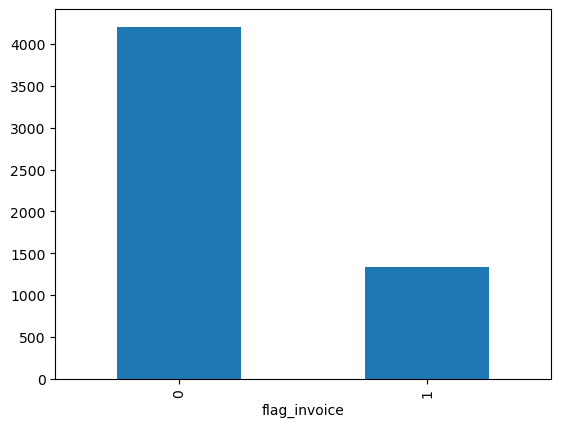

In [31]:
df["flag_invoice"].value_counts().plot(kind = 'bar')

In [32]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.007292,0.012558,0.013423,0.049442,0.059221,-0.042362,0.737584
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.002425,0.022284,0.566394,0.706117,0.668171,0.000519,0.028260
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.003092,0.025661,0.536952,0.667666,0.679537,0.004694,0.038449
Freight,0.043617,0.946550,0.985141,1.000000,0.004784,0.025513,0.536381,0.656616,0.670768,0.015645,0.033335
days_po_to_invoice,-0.007292,0.002425,0.003092,0.004784,1.000000,-0.372087,0.009547,0.002368,0.004901,0.522460,0.018185
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.372087,1.000000,0.020336,0.016203,0.015610,-0.029403,0.020767
total_brands,0.013423,0.566394,0.536952,0.536381,0.009547,0.020336,1.000000,0.783825,0.753092,0.000496,0.003866
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.002368,0.016203,0.783825,1.000000,0.963831,-0.014016,0.028260
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.004901,0.015610,0.753092,0.963831,1.000000,-0.014251,0.038449
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.522460,-0.029403,0.000496,-0.014016,-0.014251,1.000000,-0.000964


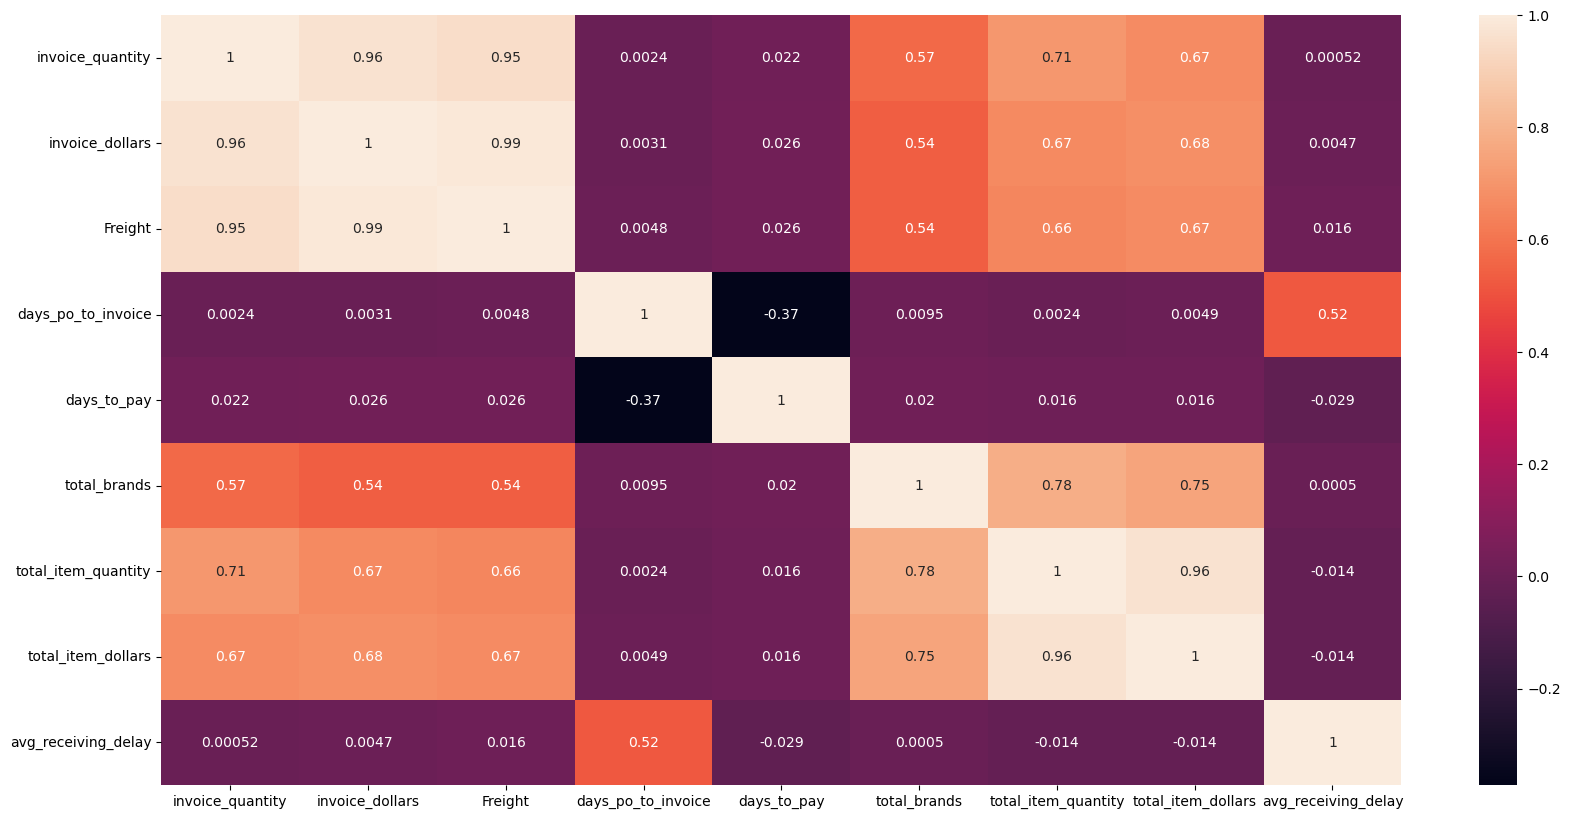

In [33]:
plt.figure(figsize = (20,10))
sns.heatmap(df.iloc[:,1:-1].corr(),annot=True)
plt.show()

In [34]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [35]:
significant_features = []
non_significant_features = []
results = []

In [36]:
metrics = ['invoice_quantity','invoice_dollars','Freight',
           'days_po_to_invoice','days_to_pay','total_brands',
           'total_item_quantity','total_item_dollars','avg_receiving_delay']

In [37]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var = False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
        "metric": metric,
        "flagged_mean": flagged_mean.round(2),
        "normal_mean": normal_mean.round(2),
        "p_value": p_value.round(3)
    })
    else:
        non_significant_features.append(metric)
        

In [38]:
non_significant_features    

['invoice_quantity',
 'days_po_to_invoice',
 'days_to_pay',
 'total_brands',
 'total_item_quantity',
 'avg_receiving_delay']

In [39]:
significant_features

['invoice_dollars', 'Freight', 'total_item_dollars']

In [40]:
results

[{'metric': 'invoice_dollars',
  'flagged_mean': np.float64(67645.33),
  'normal_mean': np.float64(55036.66),
  'p_value': np.float64(0.011)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(338.18),
  'normal_mean': np.float64(282.56),
  'p_value': np.float64(0.026)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(67645.33),
  'normal_mean': np.float64(55036.66),
  'p_value': np.float64(0.011)}]

In [41]:
X = df[['invoice_quantity','invoice_dollars','Freight',
        'total_brands','total_item_quantity',
        'days_po_to_invoice','total_item_dollars',
        'avg_receiving_delay']]

y = df['flag_invoice']

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [43]:
X_train.shape

(4434, 8)

In [44]:
X_test.shape

(1109, 8)

In [45]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0,8.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0,2.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0,3.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0,6.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0,8.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0,13.0


In [46]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier  

In [48]:
model1 = LogisticRegression(class_weight='balanced', random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(class_weight='balanced', random_state=42)
model3.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy : {acc:.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

In [50]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Regression')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Regression')


Logistic Regression Performance:
Accuracy : 0.63

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74       824
           1       0.31      0.37      0.34       285

    accuracy                           0.63      1109
   macro avg       0.54      0.54      0.54      1109
weighted avg       0.65      0.63      0.64      1109


Decision Tree Regression Performance:
Accuracy : 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       824
           1       0.92      0.88      0.90       285

    accuracy                           0.95      1109
   macro avg       0.94      0.93      0.93      1109
weighted avg       0.95      0.95      0.95      1109


Random Forest Regression Performance:
Accuracy : 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       824
     

In [51]:
model3.feature_importances_

array([0.15318161, 0.14006163, 0.12179289, 0.094739  , 0.19405176,
       0.0219949 , 0.23039858, 0.04377964])

In [52]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values( by = "importance", ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.230399
4,total_item_quantity,0.194052
0,invoice_quantity,0.153182
1,invoice_dollars,0.140062
2,Freight,0.121793
3,total_brands,0.094739
7,avg_receiving_delay,0.043780
5,days_po_to_invoice,0.021995


In [53]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars']]
y = df['flag_invoice']

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(class_weight='balanced', random_state=42)
model3.fit(X_train_scaled, y_train)

evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Regression')


Random Forest Regression Performance:
Accuracy : 0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       824
           1       1.00      0.91      0.95       285

    accuracy                           0.98      1109
   macro avg       0.98      0.95      0.97      1109
weighted avg       0.98      0.98      0.98      1109



In [55]:

param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [None, 4,5,6],
    "min_samples_split": [2,3,5],
    "min_samples_leaf": [1,2,5],
    "criterion": ['gini','entropy']
}

In [37]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(
    random_state = 42,
    n_jobs = -1
)

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    scoring = scorer,
    cv = 5,
    verbose = 2,
    n_jobs = -1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy : 0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       824
           1       1.00      0.92      0.96       285

    accuracy                           0.98      1109
   macro avg       0.99      0.96      0.97      1109
weighted avg       0.98      0.98      0.98      1109



In [38]:
from sklearn.metrics import confusion_matrix


In [39]:
confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[824,  23],
       [  0, 262]])

In [40]:
confusion_matrix(model3.predict(X_test_scaled),y_test)

array([[824,  26],
       [  0, 259]])

In [41]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}